# Step 5 — Specify Reward Function (Baseline)

This notebook completes **Step 5 only**.

Goal: define a simple linear reward, compute per-step reward components, and run sanity checks before simulator/RL training.

## What we do in this step (simple view)

1. Load `case_step_features` from Step 2.
2. Define reward parameters (`alpha`, `beta`, `delta`, `gamma`).
3. Build a per-step reward component function.
4. Compute reward diagnostics by municipality.
5. Run sanity checks and save summary outputs.

In [1]:
%pip install matplotlib

  Using cached matplotlib-3.10.8-cp314-cp314-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (52 kB)
  Using cached contourpy-1.3.3-cp314-cp314-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.62.1-cp314-cp314-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (117 kB)
  Using cached kiwisolver-1.5.0-cp314-cp314-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (5.1 kB)
  Using cached pillow-12.1.1-cp314-cp314-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (8.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached matplotlib-3.10.8-cp314-cp314-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (9.8 MB)
Using cached contourpy-1.3.3-cp314-cp314-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (363 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 10.4 MB/s eta 0:00:0

In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

OUTPUT_DIR = Path('./output')
FEATURES_PARQUET = OUTPUT_DIR / 'case_step_features.parquet'
FEATURES_CSV = OUTPUT_DIR / 'case_step_features.csv'
REWARD_STATS_PATH = OUTPUT_DIR / 'reward_stats_by_municipality.csv'
REWARD_CASE_PATH = OUTPUT_DIR / 'reward_case_summary.csv'

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print('Output dir:', OUTPUT_DIR.resolve())

Output dir: C:\Users\Lenovo\Documents\React Projects\bureaucratic-workflow-analyzer\output


In [3]:
if not FEATURES_PARQUET.exists():
    print('Error: previous notebook should be run first (Step 2 missing case_step_features.parquet).')
    raise SystemExit(1)

features_df = pd.read_parquet(FEATURES_PARQUET)
loaded_from = FEATURES_PARQUET

features_df['timestamp'] = pd.to_datetime(features_df['timestamp'], utc=True, errors='coerce')

required_cols = [
    'municipality', 'case_id', 'step_index', 'time_since_prev_hours',
    'rework_count_activity', 'is_terminal_event', 'case_completed',
    'branch_label', 'branch_confidence', 'branch_source'
]
missing = [c for c in required_cols if c not in features_df.columns]
if missing:
    raise ValueError(f'Missing required columns in case_step_features: {missing}')

print(f'Loaded {len(features_df):,} rows from {loaded_from.name}')
features_df[['municipality', 'case_id', 'branch_label', 'branch_confidence']].head(5)

Loaded 262,628 rows from case_step_features.parquet


,municipality,case_id,branch_label,branch_confidence
0,1,44688,unknown,0.0
1,1,44688,refusal,1.0
2,1,44688,refusal,1.0
3,1,44688,refusal,1.0
4,1,44688,refusal,1.0


## 5.1 Reward parameter block

We use a linear baseline reward:

$$
r_t = -\alpha\,\text{delay}_t - \beta\,\text{rework}_t - \delta\,\text{invalid}_t + \gamma\,\text{completion}_t
$$

In [4]:
# Baseline reward weights (tunable)
alpha = 0.02   # delay penalty per hour
beta = 0.75    # rework penalty per activity repeat
delta = 2.50   # invalid-action proxy penalty
gamma = 12.00  # completion bonus

delay_cap_hours = float(features_df['time_since_prev_hours'].quantile(0.95))
delay_cap_hours = max(delay_cap_hours, 1.0)

print('Reward parameters:')
print('alpha =', alpha)
print('beta  =', beta)
print('delta =', delta)
print('gamma =', gamma)
print('delay_cap_hours (95th pct):', round(delay_cap_hours, 4))

Reward parameters:
alpha = 0.02
beta  = 0.75
delta = 2.5
gamma = 12.0
delay_cap_hours (95th pct): 179.3284


## 5.2 Reward component function

`invalid_t` is approximated from uncertainty signals in Step 2 labels:
- unknown branch with low confidence, or
- ambiguous lookahead source.

This is a baseline proxy until explicit agent action validity is integrated in the environment step function.

In [5]:
def invalid_proxy_from_row(row: pd.Series) -> int:
    is_unknown_low_conf = (str(row['branch_label']) == 'unknown') and (float(row['branch_confidence']) < 0.55)
    is_ambiguous = str(row['branch_source']) == 'lookahead_ambiguous'
    return int(is_unknown_low_conf or is_ambiguous)

def reward_components(row: pd.Series, alpha, beta, delta, gamma, delay_cap_hours):
    delay_hours = float(max(row['time_since_prev_hours'], 0.0))
    delay_hours = min(delay_hours, delay_cap_hours)

    rework_count = int(max(row['rework_count_activity'], 0))
    invalid_t = invalid_proxy_from_row(row)
    completion_t = int(bool(row['case_completed']))

    delay_penalty = alpha * delay_hours
    rework_penalty = beta * rework_count
    invalid_penalty = delta * invalid_t
    completion_bonus = gamma * completion_t

    reward = -delay_penalty - rework_penalty - invalid_penalty + completion_bonus

    return {
        'delay_t': delay_hours,
        'rework_t': rework_count,
        'invalid_t': invalid_t,
        'completion_t': completion_t,
        'delay_penalty': delay_penalty,
        'rework_penalty': rework_penalty,
        'invalid_penalty': invalid_penalty,
        'completion_bonus': completion_bonus,
        'reward_t': reward
    }

In [6]:
reward_parts = features_df.apply(
    lambda row: reward_components(row, alpha, beta, delta, gamma, delay_cap_hours),
    axis=1
)
reward_df = pd.DataFrame(reward_parts.tolist())

reward_enriched = pd.concat([features_df.reset_index(drop=True), reward_df], axis=1)

reward_stats_by_municipality = (
    reward_enriched.groupby('municipality')
    .agg(
        n_rows=('reward_t', 'size'),
        reward_mean=('reward_t', 'mean'),
        reward_median=('reward_t', 'median'),
        reward_std=('reward_t', 'std'),
        delay_penalty_mean=('delay_penalty', 'mean'),
        rework_penalty_mean=('rework_penalty', 'mean'),
        invalid_penalty_mean=('invalid_penalty', 'mean'),
        completion_bonus_mean=('completion_bonus', 'mean'),
        invalid_rate=('invalid_t', 'mean')
    )
    .reset_index()
    .sort_values('municipality')
    .reset_index(drop=True)
)

reward_stats_by_municipality.to_csv(REWARD_STATS_PATH, index=False)
print('Saved:', REWARD_STATS_PATH.resolve())
reward_stats_by_municipality

Saved: C:\Users\Lenovo\Documents\React Projects\bureaucratic-workflow-analyzer\output\reward_stats_by_municipality.csv


,municipality,n_rows,reward_mean,reward_median,reward_std,delay_penalty_mean,rework_penalty_mean,invalid_penalty_mean,completion_bonus_mean,invalid_rate
0,1,52217,-1.264561,-0.750000,1.885754,0.310787,0.061661,1.051142,0.159029,0.420457
1,2,44354,-1.377478,-2.400000,1.853633,0.264326,0.062954,1.177628,0.127429,0.471051
2,3,59681,-1.247183,-0.750000,1.851508,0.251887,0.065461,1.082045,0.152209,0.432818
3,4,47293,-1.203131,-0.232533,1.898527,0.294936,0.046133,1.016588,0.154526,0.406635
4,5,59083,-1.134390,-0.262133,1.964952,0.266150,0.057593,0.998722,0.188074,0.399489


Saved: C:\Users\Lenovo\Documents\React Projects\bureaucratic-workflow-analyzer\output\reward_case_summary.csv


<Figure size 1000x400 with 0 Axes>

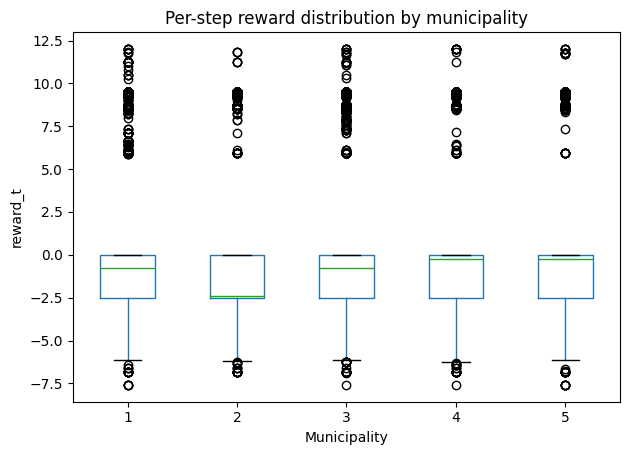

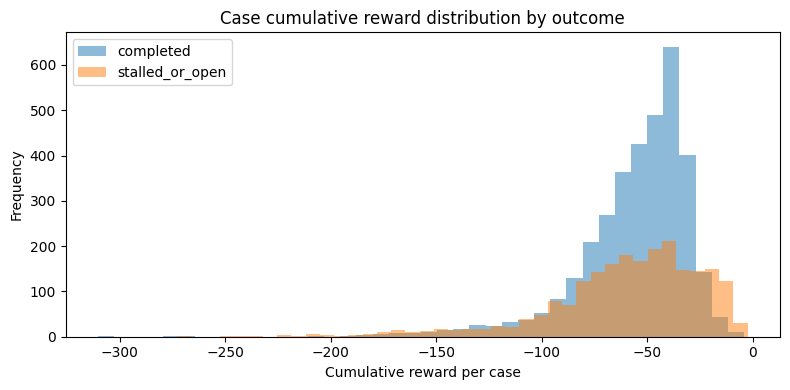

,municipality,case_id,cumulative_reward,case_completed_any,n_steps,case_outcome
0,1,44688,-43.722071,False,43,stalled_or_open
1,1,46057,-97.213299,False,63,stalled_or_open
2,1,47962,-26.828226,True,35,completed
3,1,47963,-48.499508,True,48,completed
4,1,47964,-42.571758,True,35,completed
5,1,47965,-17.478140,False,21,stalled_or_open
6,1,47966,-42.404539,True,45,completed
7,1,47967,-35.186361,True,45,completed
8,1,47968,-36.994667,True,45,completed
9,1,47969,-96.879114,False,61,stalled_or_open


In [7]:
# Case-level cumulative reward for sanity checks
case_summary = (
    reward_enriched.groupby(['municipality', 'case_id'])
    .agg(
        cumulative_reward=('reward_t', 'sum'),
        case_completed_any=('case_completed', 'max'),
        n_steps=('step_index', 'size')
    )
    .reset_index()
)

case_summary['case_outcome'] = np.where(case_summary['case_completed_any'] > 0, 'completed', 'stalled_or_open')
case_summary.to_csv(REWARD_CASE_PATH, index=False)
print('Saved:', REWARD_CASE_PATH.resolve())

# Plot 1: reward distribution by municipality
# How to read the plot ?
# The boxplot shows the distribution of per-step rewards for each municipality. The central line in each box represents the median reward, the edges of the box represent the interquartile range (IQR), and the whiskers extend to show the range of rewards within 1.5 * IQR from the quartiles. Points outside this range are shown as individual dots (outliers). By comparing the boxes across municipalities, we can see if there are differences in reward distributions, which may indicate variations in process efficiency or areas for improvement.
plt.figure(figsize=(10, 4))
reward_enriched.boxplot(column='reward_t', by='municipality', grid=False)
plt.title('Per-step reward distribution by municipality')
plt.suptitle('')
plt.xlabel('Municipality')
plt.ylabel('reward_t')
plt.tight_layout()
plt.show()

# Plot 2: case cumulative reward by outcome
plt.figure(figsize=(8, 4))
for label, grp in case_summary.groupby('case_outcome'):
    values = grp['cumulative_reward'].dropna().values
    if len(values) > 0:
        plt.hist(values, bins=40, alpha=0.5, label=label)
plt.title('Case cumulative reward distribution by outcome')
plt.xlabel('Cumulative reward per case')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()

case_summary.head(10)

In [8]:
# Sanity checks
completed_cases = case_summary[case_summary['case_outcome'] == 'completed']['cumulative_reward']
stalled_cases = case_summary[case_summary['case_outcome'] == 'stalled_or_open']['cumulative_reward']

completed_median = float(completed_cases.median()) if len(completed_cases) else np.nan
stalled_median = float(stalled_cases.median()) if len(stalled_cases) else np.nan
check_completed_beats_stalled = bool(completed_median > stalled_median) if np.isfinite(completed_median) and np.isfinite(stalled_median) else False

tiny_delay_diff = 0.01  # hours
tiny_delay_penalty = alpha * tiny_delay_diff
check_invalid_dominates_tiny_delay = bool(delta > tiny_delay_penalty)

print('Completed median cumulative reward:', round(completed_median, 4))
print('Stalled/open median cumulative reward:', round(stalled_median, 4))
# This validates that the reward function is roughly aligned with the desired outcome, i.e. completed cases should have higher rewards than stalled/open cases
print('Check A - completed > stalled median:', check_completed_beats_stalled)

print('\ndelta:', delta)
print('alpha * tiny_delay_diff:', round(tiny_delay_penalty, 6))
# This validates that the invalid action penalty is sufficiently large to dominate small differences in delay penalties to prioritize avoiding invalid actions
print('Check B - invalid penalty dominates tiny delay diff:', check_invalid_dominates_tiny_delay)

Completed median cumulative reward: -50.0568
Stalled/open median cumulative reward: -53.4403
Check A - completed > stalled median: True

delta: 2.5
alpha * tiny_delay_diff: 0.0002
Check B - invalid penalty dominates tiny delay diff: True


## Step 5 complete

You now have a baseline reward function with per-step components and sanity diagnostics.

Saved outputs:
- `./output/reward_stats_by_municipality.csv`
- `./output/reward_case_summary.csv`

Next step: build calibrated SimPy simulator (Step 6).